In [30]:
# imports
%load_ext tensorboard

import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator             # 이미지가 부족할 때 사용하여 이미지를 생성할 수 있다. 레지넷은 괸당이 많은 데잍ㅓ를 요구한다.
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [31]:
num_classes = 2                                                                 # 개와 고양이이기 때문에 classes = 2
class Alexnet(Sequential) :                                                     # 요즘은 computing power가 좋아서 병렬처리 안하고 그냥 한다.
  def __init__(self, input_shape, num_classes) :
    super().__init__()

    self.add(Conv2D(96, kernel_size = (11, 11), strides = 4,
             padding = 'valid', activation = 'relu',
             input_shape= input_shape, kernel_initializer = 'he_normal'))       # 가중치를 초기화하는 방법을 지정하는거다 'he_normal'

    self.add(MaxPooling2D(pool_size=(3, 3), strides = (2, 2),
                          padding = 'valid', data_format=None))                 # data_format default : channels_last (배치크기, 높이, 너비, 채널) --> 파라미터들중에 채널정보가 뒤에 온다는 거
    
    self.add(Conv2D(256, kernel_size = (5, 5), strides = 1,
                    padding='same', activation='relu',
                    kernel_initializer='he_normal'))
    
    self.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2),
                          padding='valid', data_format=None))
    
    self.add(Conv2D(384, kernel_size = (3, 3), strides = 1,
                    padding='same', activation='relu',
                    kernel_initializer='he_normal'))
    
    self.add(Conv2D(384, kernel_size = (3, 3), strides = 1,
                    padding='same', activation='relu',
                    kernel_initializer='he_normal'))
    
    self.add(Conv2D(256, kernel_size = (3, 3), strides = 1,
                    padding='same', activation='relu',
                    kernel_initializer='he_normal'))
    
    self.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2),
                          padding='valid', data_format=None))
    
    # 일차원으로 만들고 합성곱 신경망 통과시키기 
    self.add(Flatten())
    self.add(Dense(4096, activation='relu'))
    self.add(Dense(4096, activation='relu'))
    self.add(Dense(1000, activation='relu'))                                    # 원래 이 모델은 1000classes를 구분하는 모델이었기 때문에 아웃풋 1000
    self.add(Dense(num_classes, activation='softmax'))                          # softmax를 사용한다 (이진분류이긴 하지만 뭐 안될거 없잖아?)
    #self.add(Dense(num_classes, activation='sigmoid'))                          

    self.compile(optimizer = tf.keras.optimizers.Adam(0.001),
                 loss = 'categorical_crossentropy',
                 #loss = 'binary_crossentropy',
                 metrics = ['accuracy'])

In [32]:
model = Alexnet((100, 100, 3), num_classes)
model.summary()

Model: "alexnet_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_25 (Conv2D)           (None, 23, 23, 96)        34944     
_________________________________________________________________
max_pooling2d_15 (MaxPooling (None, 11, 11, 96)        0         
_________________________________________________________________
conv2d_26 (Conv2D)           (None, 11, 11, 256)       614656    
_________________________________________________________________
max_pooling2d_16 (MaxPooling (None, 5, 5, 256)         0         
_________________________________________________________________
conv2d_27 (Conv2D)           (None, 5, 5, 384)         885120    
_________________________________________________________________
conv2d_28 (Conv2D)           (None, 5, 5, 384)         1327488   
_________________________________________________________________
conv2d_29 (Conv2D)           (None, 5, 5, 256)         88

In [33]:
EPOCHS = 100
BATCH_SIZE = 32
image_height = 100
image_width = 100
train_dir = '/content/drive/MyDrive/catanddog/train/'
valid_dir = '/content/drive/MyDrive/catanddog/validation/'

In [34]:
# 어제와 동일한 것
train = ImageDataGenerator(
                  rescale=1./255,
                  rotation_range=10,
                  width_shift_range=0.1,
                  height_shift_range=0.1,
                  shear_range=0.1,
                  zoom_range=0.1)

train_generator = train.flow_from_directory(train_dir,
                                                    target_size=(image_height, image_width),
                                                    color_mode="rgb",
                                                    batch_size=BATCH_SIZE,
                                                    seed=1,
                                                    shuffle=True,
                                                    class_mode="categorical")

valid = ImageDataGenerator(rescale=1.0/255.0)
valid_generator = valid.flow_from_directory(valid_dir,
                                                    target_size=(image_height, image_width),
                                                    color_mode="rgb",
                                                    batch_size=BATCH_SIZE,
                                                    seed=7,
                                                    shuffle=True,
                                                    class_mode="categorical"
                                                    )
train_num = train_generator.samples
valid_num = valid_generator.samples

Found 385 images belonging to 2 classes.
Found 98 images belonging to 2 classes.


In [35]:
# 모델 학습
model.fit(train_generator,
          epochs = EPOCHS,
          steps_per_epoch = train_num // BATCH_SIZE,
          validation_data = valid_generator,
          validation_steps = valid_num // BATCH_SIZE,
          verbose = 1)

Epoch 1/100
12/12 [==============================] - 4s 289ms/step - loss: 0.8909 - accuracy: 0.5354 - val_loss: 0.9068 - val_accuracy: 0.5000
Epoch 2/100
12/12 [==============================] - 3s 257ms/step - loss: 0.7121 - accuracy: 0.5269 - val_loss: 0.6943 - val_accuracy: 0.5000
Epoch 3/100
12/12 [==============================] - 3s 268ms/step - loss: 0.6933 - accuracy: 0.4974 - val_loss: 0.6936 - val_accuracy: 0.4896
Epoch 4/100
12/12 [==============================] - 3s 259ms/step - loss: 0.6977 - accuracy: 0.5212 - val_loss: 0.6937 - val_accuracy: 0.5000
Epoch 5/100
12/12 [==============================] - 3s 259ms/step - loss: 0.6921 - accuracy: 0.5241 - val_loss: 0.6944 - val_accuracy: 0.4896
Epoch 6/100
12/12 [==============================] - 3s 268ms/step - loss: 0.6898 - accuracy: 0.5286 - val_loss: 0.6919 - val_accuracy: 0.5104
Epoch 7/100
12/12 [==============================] - 3s 267ms/step - loss: 0.6894 - accuracy: 0.5156 - val_loss: 0.6931 - val_accuracy: 0.5417

/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/sequential.py:455: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


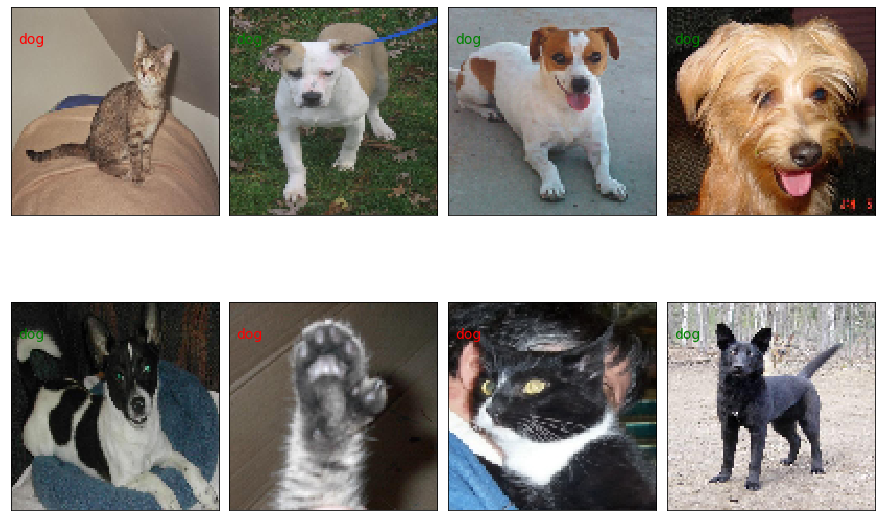

In [36]:
class_names = ['cat', 'dog']
validation, label_batch = next(iter(valid_generator))
prediction_values = model.predict_classes(validation)

fig = plt.figure(figsize = (12, 8))
fig.subplots_adjust(left = 0, right = 1, bottom = 0, top = 1, hspace = 0.05, wspace = 0.05)

for i in range(8) :
  ax = fig.add_subplot(2, 4, i + 1, xticks = [], yticks = [])
  ax.imshow(validation[i, :], cmap = plt.cm.gray_r, interpolation = 'nearest')

  # 올바른 예측은 초록색, 잘못된 예측은 빨간색
  if prediction_values[i] == np.argmax(label_batch[i]) : 
    ax.text(3, 17, class_names[prediction_values[i]], color = 'green', fontsize = 14)
  
  else : 
    ax.text(3, 17, class_names[prediction_values[i]], color = 'red', fontsize = 14)
